In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import random

In [88]:
import kagglehub

# Download latest version
#path = kagglehub.dataset_download("lakshmi25npathi/online-retail-dataset")

#print("Path to dataset files:", path)

In [89]:
df = pd.read_excel(r"./datasets/online_retail_II.xlsx")


# **hacer un ensuciado de datos**

In [90]:
df_dirty = df.copy()
# 1. AGREGAR VALORES NULOS (10-15% aleatorio)
np.random.seed(42)
null_cols = ['Description', 'Customer ID', 'Country', 'Price', 'Quantity']

for col in null_cols:
    null_idx = np.random.choice(df_dirty.index,
                                size=int(len(df_dirty) * np.random.uniform(0.05, 0.15)),
                                replace=False)
    df_dirty.loc[null_idx, col] = np.nan
# 2. AGREGAR VALORES ATÍPICOS (outliers)
# Cantidades negativas o extremadamente grandes
neg_qty_idx = np.random.choice(df_dirty.index, size=500, replace=False)
df_dirty.loc[neg_qty_idx, 'Quantity'] = -np.random.randint(1, 100, 500)

# Precios extremos (negativos o muy altos)
extreme_price_idx = np.random.choice(df_dirty.index, size=300, replace=False)
df_dirty.loc[extreme_price_idx, 'Price'] = np.random.choice([-10, -50, 9999, 50000, 0.001], 300)
# 3. FORMATOS INCORRECTOS EN FECHAS
df_dirty['InvoiceDate'] = df_dirty['InvoiceDate'].astype('object')
date_idx = np.random.choice(df_dirty.index, size=200, replace=False)
for idx in date_idx:
    # Convertir algunas fechas a string con formato incorrecto
    df_dirty.loc[idx, 'InvoiceDate'] = np.random.choice([
        '2023-13-01',  # mes inválido
        '01/01/23',    # formato diferente
        'invalid_date',
        '2023-02-29',  # fecha inválida
        'Jan 1, 2023'
    ])
# 4. DATOS DUPLICADOS (agregar ~1000 filas duplicadas)
dup_indices = np.random.choice(df_dirty.index, size=1000, replace=True)
df_duplicates = df_dirty.loc[dup_indices].copy()
df_dirty = pd.concat([df_dirty, df_duplicates], ignore_index=True)

# 5. TEXTOS CON ERRORES EN 'Description'
# Minúsculas, mayúsculas, espacios, typos
desc_idx = np.random.choice(df_dirty.index, size=2000, replace=False)
for idx in desc_idx:
    if pd.notna(df_dirty.loc[idx, 'Description']):
        current = str(df_dirty.loc[idx, 'Description'])
        error_type = np.random.choice(['lower', 'upper', 'spaces', 'typo', 'mixed'])

        if error_type == 'lower':
            df_dirty.loc[idx, 'Description'] = current.lower()
        elif error_type == 'upper':
            df_dirty.loc[idx, 'Description'] = current.upper()
        elif error_type == 'spaces':
            df_dirty.loc[idx, 'Description'] = '  ' + current + '   '
        elif error_type == 'typo':
            df_dirty.loc[idx, 'Description'] = current.replace('a', '@').replace('e', '3')
        elif error_type == 'mixed':
            df_dirty.loc[idx, 'Description'] = current[:5].upper() + current[5:].lower()
# 6. ERRORES EN 'Customer ID' (valores no numéricos)
df_dirty['Customer ID'] = df_dirty['Customer ID'].astype('object')

cust_idx = np.random.choice(df_dirty.index, size=500, replace=False)
df_dirty.loc[cust_idx, 'Customer ID'] = np.random.choice(['ABC123', 'N/A', 'unknown', '#N/A', ''], 500)


# 8. PAÍSES CON NOMBRES INCONSISTENTES
df_dirty['Country'] = df_dirty['Country'].astype('object')

country_idx = np.random.choice(df_dirty.index, size=1000, replace=False)
country_variations = {
    'United Kingdom': ['UK', 'U.K.', 'England', 'uk', 'United Kingdom ', 'GB'],
    'USA': ['US', 'U.S.A.', 'America', 'usa', 'United States'],
    'Germany': ['DE', 'Deutschland', 'germany', 'GER'],
    'France': ['FR', 'france', 'FRA', 'Francia']
}

for idx in country_idx:
    if pd.notna(df_dirty.loc[idx, 'Country']):
        country = df_dirty.loc[idx, 'Country']
        for standard, variations in country_variations.items():
            if country == standard:
                df_dirty.loc[idx, 'Country'] = np.random.choice(variations)
                break



In [91]:
df_dirty['sex'] = np.random.choice(['Male', 'Female'], size=len(df_dirty))


In [92]:
df_dirty['isMale'] = (df_dirty['sex'] == 'Male').astype(int)
df_dirty['isFemale'] = (df_dirty['sex'] == 'Female').astype(int)

# EDA inicial: nulls, duplicados y estadísticas

Exploración rápida de df_dirty para detectar nulos, duplicados, tipos de datos y estadísticas clave.



In [93]:
df_dirty.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,sex,isMale,isFemale
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Male,1,0


In [94]:
df_dirty['sex'].value_counts()

sex
Male      263345
Female    263116
Name: count, dtype: int64

In [95]:
df_dirty.info()

<class 'pandas.DataFrame'>
RangeIndex: 526461 entries, 0 to 526460
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      526461 non-null  object 
 1   StockCode    526461 non-null  object 
 2   Description  477728 non-null  object 
 3   Quantity     455275 non-null  float64
 4   InvoiceDate  526461 non-null  object 
 5   Price        488431 non-null  float64
 6   Customer ID  369437 non-null  object 
 7   Country      491712 non-null  object 
 8   sex          526461 non-null  str    
 9   isMale       526461 non-null  int64  
 10  isFemale     526461 non-null  int64  
dtypes: float64(2), int64(2), object(6), str(1)
memory usage: 44.2+ MB


In [96]:
df_dirty.describe()

,Quantity,Price,isMale,isFemale
count,455275.000000,488431.000000,526461.000000,526461.000000
mean,10.198873,11.861648,0.500217,0.499783
std,105.206526,576.071363,0.500000,0.500000
min,-9600.000000,-53594.360000,0.000000,0.000000
25%,1.000000,1.250000,0.000000,0.000000
50%,3.000000,2.100000,1.000000,0.000000
75%,10.000000,4.210000,1.000000,1.000000
max,19152.000000,50000.000000,1.000000,1.000000


In [97]:
pd.DataFrame({
    'nulls': df_dirty.isnull().sum(),
    'unique': df_dirty.duplicated().sum(),
    'shape' :df_dirty.shape[0]
})

,nulls,unique,shape
Invoice,0,1870,526461
StockCode,0,1870,526461
Description,48733,1870,526461
Quantity,71186,1870,526461
InvoiceDate,0,1870,526461
Price,38030,1870,526461
Customer ID,157024,1870,526461
Country,34749,1870,526461
sex,0,1870,526461
isMale,0,1870,526461


# **SNAKE CASE**

In [98]:
print(type(df_dirty))

<class 'pandas.DataFrame'>


In [99]:
df_dirty.columns = (df_dirty.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(r'\s+', '_', regex=True)
                    .str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True)
                    .str.replace('__', '_', regex=True)
                    .str.strip('_')
                    )


In [100]:
df_dirty.head(1)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,sex,ismale,isfemale
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Male,1,0


In [101]:
def to_snake(x):
    if isinstance(x, str):
        x = x.strip().lower()
        x = re.sub(r'[^a-z0-9]+', '_', x)  # todo lo raro → _
        x = re.sub(r'_+', '_', x)          # evita ___
        return x.strip('_')               # quita _ al inicio/fin
    return x
df_dirty = df_dirty.apply(lambda col: col.map(to_snake))

In [102]:
df_dirty.head(1)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,sex,ismale,isfemale
0,489434,85048,15cm_christmas_glass_ball_20_lights,12.0,2009-12-01 07:45:00,6.95,13085.0,united_kingdom,male,1,0


# Detectamos Valores atipicos Outliers

<Axes: xlabel='variable', ylabel='value'>

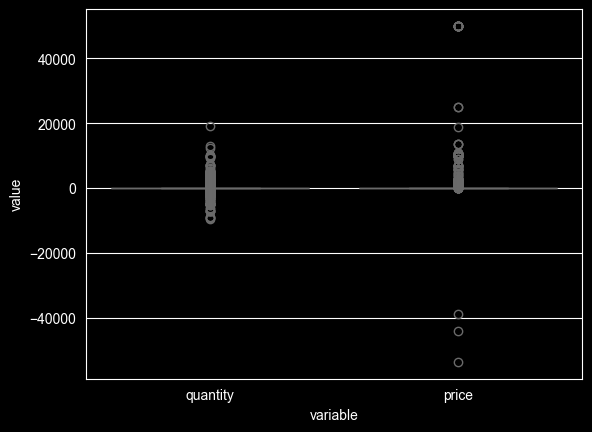

In [103]:
sns.boxplot(
    data=df_dirty.melt(value_vars=['quantity','price']),
    x='variable',
    y='value'
)

In [104]:
from numpy import percentile

outliers={}
for col in df_dirty.select_dtypes(include='number').columns:
  Q1 = df_dirty[col].quantile(0.25)
  Q3 = df_dirty[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  mask = (df_dirty[col] < lower) | (df_dirty[col] > upper)

  outliers[col] = df_dirty[(df_dirty[col] < lower) | (df_dirty[col] > upper)][col]

  if col != 'quantity':
      media = df_dirty[col].mean().round()
      df_dirty.loc[mask, col] = df_dirty[col].median()

for i in outliers:
  print(i)



quantity
price
ismale
isfemale


# Limpieza de Datos

In [105]:
df_dirty = df_dirty[df_dirty["customer_id"].notna()]

df_dirty["description"] = df_dirty["description"].fillna("unknown")
df_dirty["country"] = df_dirty["country"].fillna(df_dirty["country"].mode()[0])

df_dirty["price"] = df_dirty["price"].fillna(df_dirty["price"].median())
df_dirty = df_dirty[df_dirty["quantity"].notna()]

df_dirty["invoicedate"] = pd.to_datetime(df_dirty["invoicedate"], errors="coerce")
df_dirty = df_dirty[df_dirty["invoicedate"].notna()]

**verificacion y eliminacion duplicados**


In [106]:
df_dirty.duplicated().sum()

np.int64(1775)

In [107]:
df_dirty = df_dirty.drop_duplicates()

In [108]:
pd.DataFrame({
    'nulls': df_dirty.isnull().sum(),
    'unique': df_dirty.duplicated().sum(),
    'shape' :df_dirty.shape[0]
})

,nulls,unique,shape
invoice,0,0,317625
stockcode,0,0,317625
description,0,0,317625
quantity,0,0,317625
invoicedate,0,0,317625
price,0,0,317625
customer_id,0,0,317625
country,0,0,317625
sex,0,0,317625
ismale,0,0,317625


In [109]:
df_dirty.head(1)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,sex,ismale,isfemale
0,489434,85048,15cm_christmas_glass_ball_20_lights,12.0,2009-12-01 07:45:00,6.95,13085.0,united_kingdom,male,1,0


In [110]:
df_dirty["country"].unique()

<StringArray>
[      'united_kingdom',               'france',                  'usa',
              'belgium',            'australia',                   'gb',
                 'eire',              'germany',             'portugal',
                  'u_k',                'japan',                   'uk',
              'denmark',          'netherlands',               'poland',
                'spain',      'channel_islands',                'italy',
              'england',               'cyprus',               'greece',
               'norway',              'austria',               'sweden',
 'united_arab_emirates',              'finland',          'switzerland',
          'unspecified',                'malta',                  'rsa',
          'deutschland',                   'de',            'singapore',
                   'fr',              'francia',              'bahrain',
             'thailand',               'israel',            'lithuania',
              'nigeria',          'we

In [111]:
from utils.valid_countries import normalize_country

df_dirty["country"] = df_dirty["country"].apply(normalize_country)

In [112]:
df_dirty["country"].unique()

<StringArray>
[      'united_kingdom',               'france',                  'usa',
              'belgium',            'australia',              'germany',
              'ireland',             'portugal',                'japan',
              'denmark',          'netherlands',          'switzerland',
                'spain',              'finland',                'italy',
               'greece',               'norway',              'austria',
               'sweden', 'united_arab_emirates',              'bahrain',
              'nigeria',          'west_indies',                'korea',
               'brazil',               'canada']
Length: 26, dtype: str

In [113]:
df_dirty[df_dirty['quantity'] < 0]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,sex,ismale,isfemale
178,c489449,22087,paper_bunting_white_lace,-12.0,2009-12-01 10:33:00,2.95,16321.0,australia,male,1,0
180,c489449,21895,potting_shed_sow_n_grow_set,-4.0,2009-12-01 10:33:00,4.25,16321.0,australia,male,1,0
182,c489449,22083,paper_chain_kit_retro_spot,-12.0,2009-12-01 10:33:00,2.95,16321.0,australia,male,1,0
183,c489449,21871,unknown,-12.0,2009-12-01 10:33:00,1.25,16321.0,australia,female,0,1
184,c489449,84946,antique_silver_tea_glass_etched,-12.0,2009-12-01 10:33:00,1.25,16321.0,australia,female,0,1
...,...,...,...,...,...,...,...,...,...,...,...
525611,c489858,22198,popcorn_holder_large,-7.0,2009-12-02 14:43:00,1.65,12471.0,germany,male,1,0
525640,c497159,21071,vintage_billboard_drink_me_mug,-1.0,2010-02-05 16:31:00,1.06,13078.0,united_kingdom,female,0,1
525897,c538118,47594a,carousel_design_washbag,-1.0,2010-12-09 15:33:00,1.95,17700.0,united_kingdom,female,0,1
526031,c491417,22061,large_cake_stand_hanging_strawbery,-1.0,2009-12-10 19:20:00,2.10,15079.0,united_kingdom,male,1,0


In [114]:
df_dirty.loc[df_dirty['quantity'] < 0, 'quantity'] = 0

In [115]:
df_dirty[df_dirty['quantity'] < 0]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,sex,ismale,isfemale
